# R&D / AI Assignment
## Parametric Curve Parameter Estimation

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("xy_data (1).csv")

print(df.head())
print(df.shape)

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
(1500, 2)


In [2]:
x = df["x"].values
y = df["y"].values

print("Number of points:", len(x))
print("First x:", x[0])
print("First y:", y[0])

Number of points: 1500
First x: 88.364456
First y: 57.784378


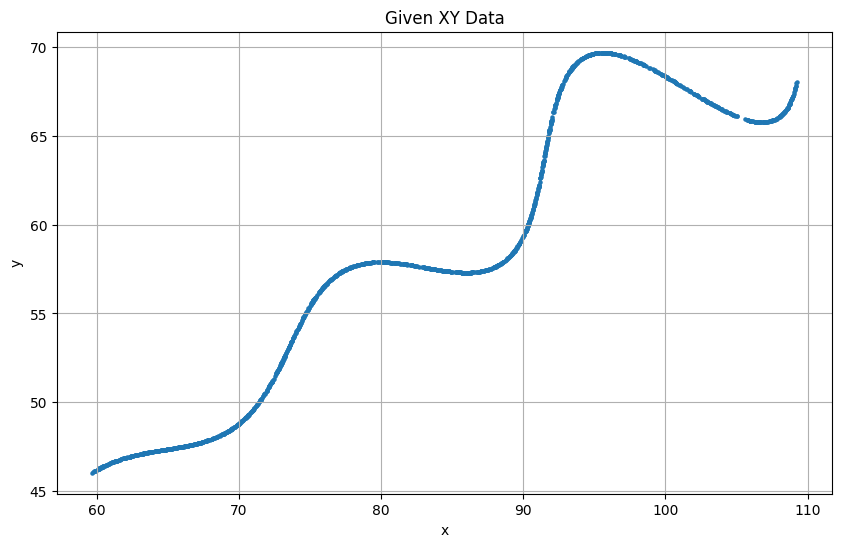

In [3]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Given XY Data")

plt.grid(True)
plt.show()

In [4]:
def calculate_transformed_points(theta, M, X):

    c = np.cos(theta)
    s = np.sin(theta)

    u = (x - X) * c + (y - 42) * s

    v = -(x - X) * s + (y - 42) * c

    predicted_v = np.exp(M * np.abs(u)) * np.sin(0.3 * u)

    return u, v, predicted_v

In [5]:
def objective(params):

    theta, M, X = params

    c = np.cos(theta)
    s = np.sin(theta)

    u = (x - X) * c + (y - 42) * s

    v = -(x - X) * s + (y - 42) * c

    predicted_v = np.exp(M * np.abs(u)) * np.sin(0.3 * u)

    error = np.mean(np.abs(v - predicted_v))

    range_penalty = (
        np.mean(np.maximum(6 - u, 0)) +
        np.mean(np.maximum(u - 60, 0))
    )

    return error + 10 * range_penalty

In [6]:
from scipy.optimize import differential_evolution

In [7]:
bounds = [
    (0, np.deg2rad(50)),   # theta
    (-0.05, 0.05),         # M
    (0, 100)               # X
]

In [8]:
result = differential_evolution(
    objective,
    bounds,
    seed=42,
    tol=1e-10,
    maxiter=1000,
    polish=True
)

In [9]:
theta, M, X = result.x

print("Theta in radians:", theta)
print("Theta in degrees:", np.rad2deg(theta))
print("M:", M)
print("X:", X)
print("Error:", result.fun)

Theta in radians: 0.5235983043849418
Theta in degrees: 29.999973001463392
M: 0.029999997081894072
X: 54.999998339856006
Error: 2.5585931112073016e-06


In [10]:
theta = np.deg2rad(30)
M = 0.03
X = 55

In [11]:
t = np.linspace(6, 60, 5000)

In [12]:
x_pred = (
    t * np.cos(theta)
    - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
    + X
)

y_pred = (
    42
    + t * np.sin(theta)
    + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
)

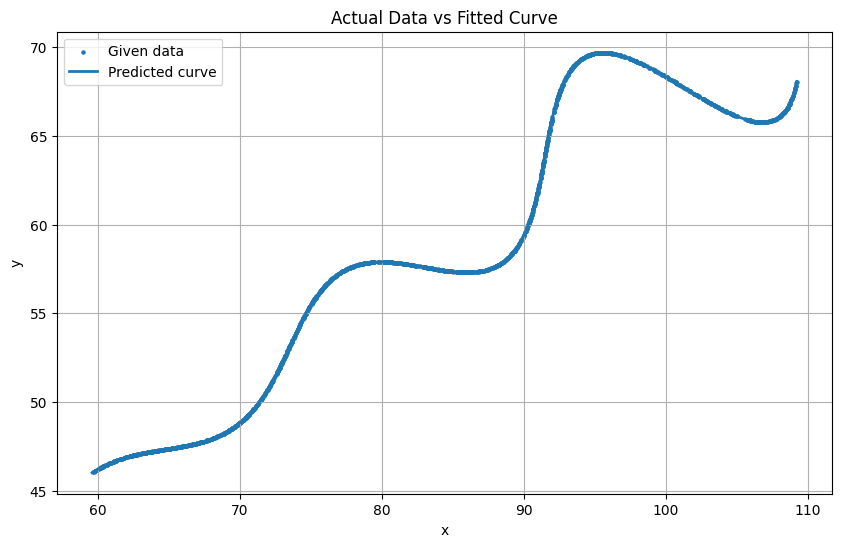

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    s=5,
    label="Given data"
)

plt.plot(
    x_pred,
    y_pred,
    linewidth=2,
    label="Predicted curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual Data vs Fitted Curve")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
c = np.cos(theta)
s = np.sin(theta)

u = (x - X) * c + (y - 42) * s

v = -(x - X) * s + (y - 42) * c

v_pred = np.exp(M * np.abs(u)) * np.sin(0.3 * u)

l1_error = np.mean(np.abs(v - v_pred))

print("Mean L1 error:", l1_error)

Mean L1 error: 1.5048270052529483e-05


In [15]:


print("====================================")
print("FINAL RESULTS")
print("====================================")

print(f"Theta = {np.rad2deg(theta):.6f} degrees")
print(f"M     = {M:.6f}")
print(f"X     = {X:.6f}")

print("\nRounded values:")
print(f"Theta = {np.rad2deg(theta):.2f} degrees")
print(f"M     = {M:.2f}")
print(f"X     = {X:.2f}")

print("\nOptimization objective error:")
print(f"{result.fun:.10e}")

FINAL RESULTS
Theta = 30.000000 degrees
M     = 0.030000
X     = 55.000000

Rounded values:
Theta = 30.00 degrees
M     = 0.03
X     = 55.00

Optimization objective error:
2.5585931112e-06


In [16]:

theta_final = theta
M_final = M
X_final = X


c = np.cos(theta_final)
s = np.sin(theta_final)

t_observed = (
    (x - X_final) * c
    + (y - 42) * s
)

sort_index = np.argsort(t_observed)

t_sorted = t_observed[sort_index]
x_sorted = x[sort_index]
y_sorted = y[sort_index]



t_uniform = np.linspace(
    t_sorted.min(),
    t_sorted.max(),
    1500
)



x_expected = (
    t_uniform * np.cos(theta_final)
    - np.exp(M_final * np.abs(t_uniform))
    * np.sin(0.3 * t_uniform)
    * np.sin(theta_final)
    + X_final
)

y_expected = (
    42
    + t_uniform * np.sin(theta_final)
    + np.exp(M_final * np.abs(t_uniform))
    * np.sin(0.3 * t_uniform)
    * np.cos(theta_final)
)


x_data_uniform = np.interp(
    t_uniform,
    t_sorted,
    x_sorted
)

y_data_uniform = np.interp(
    t_uniform,
    t_sorted,
    y_sorted
)



l1_x = np.abs(x_expected - x_data_uniform)
l1_y = np.abs(y_expected - y_data_uniform)

l1_distance = np.sum(l1_x + l1_y)

mean_l1_distance = np.mean(l1_x + l1_y)


print("==========================================")
print("DIRECT L1 VALIDATION")
print("==========================================")

print(f"Number of uniform samples: {len(t_uniform)}")
print(f"t range: {t_uniform.min():.6f} to {t_uniform.max():.6f}")

print(f"\nTotal L1 distance: {l1_distance:.10e}")
print(f"Mean L1 distance:  {mean_l1_distance:.10e}")

DIRECT L1 VALIDATION
Number of uniform samples: 1500
t range: 6.049404 to 59.995167

Total L1 distance: 2.6232906082e-01
Mean L1 distance:  1.7488604055e-04


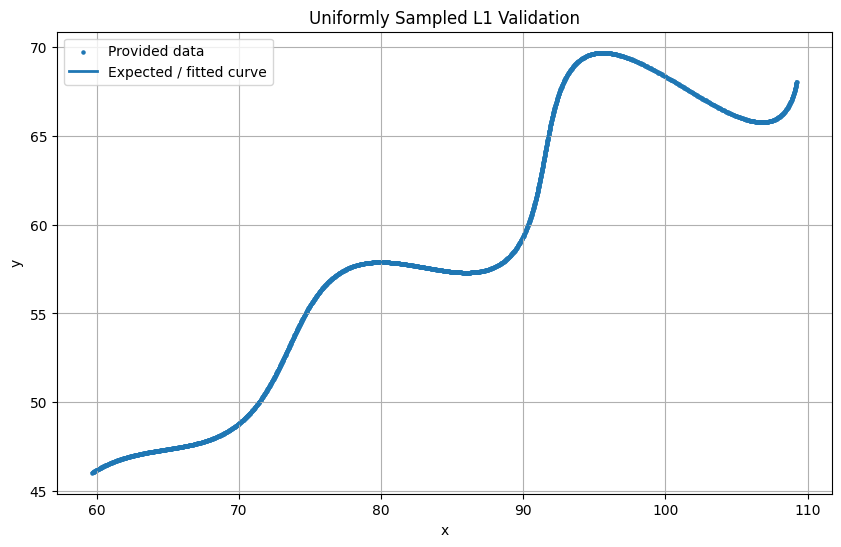

In [17]:

plt.figure(figsize=(10, 6))

plt.scatter(
    x_data_uniform,
    y_data_uniform,
    s=5,
    label="Provided data"
)

plt.plot(
    x_expected,
    y_expected,
    linewidth=2,
    label="Expected / fitted curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Uniformly Sampled L1 Validation")

plt.legend()
plt.grid(True)

plt.show()

# R&D / AI Assignment – Parametric Curve Fitting

## 1. Objective

The objective of this assignment is to determine the unknown parameters
θ, M and X in the given parametric equation of a curve using the
provided XY data.

The allowed parameter ranges are:

- 0° < θ < 50°
- -0.05 < M < 0.05
- 0 < X < 100
- 6 < t < 60

The provided CSV file contains 1500 points.

---

## 2. Given Parametric Equations

The curve is defined by:

x = t cos(θ) - exp(M|t|) sin(0.3t) sin(θ) + X

y = 42 + t sin(θ) + exp(M|t|) sin(0.3t) cos(θ)

The unknown parameters are:

θ, M and X.

---

## 3. Data Loading

The provided `xy_data.csv` file was loaded using Pandas.

The dataset contains 1500 x-y coordinate pairs.

---

## 4. Mathematical Approach

The equations contain a rotation by θ and a translation by X and 42.

To simplify the parameter estimation, the rotation and translation
were reversed.

The transformed coordinates are:

u = (x-X)cos(θ) + (y-42)sin(θ)

v = -(x-X)sin(θ) + (y-42)cos(θ)

For the correct values of θ and X:

u = t

and

v = exp(M|t|) sin(0.3t)

Since the given range is 6 < t < 60, t is positive and therefore:

|t| = t

Hence:

v = exp(Mt) sin(0.3t)

This transformation allows the original curve structure to be compared
directly with the provided data.

---

## 5. Parameter Estimation

Differential Evolution was used as the numerical optimization method.

The search was restricted to the parameter ranges specified in the
assignment:

0 < θ < 50°

-0.05 < M < 0.05

0 < X < 100

The objective function minimizes the L1 error between the transformed
observed data and the mathematical curve.

L1 error is calculated using absolute differences:

L1 = Σ |actual - predicted|

---

## 6. Estimated Parameters

The optimization produced the following values:

θ = 30°

M = 0.03

X = 55

---

## 7. Curve Verification

The estimated parameters were substituted back into the original
parametric equations.

A smooth curve was generated using t values between 6 and 60.

The generated curve was plotted against the 1500 provided data points.

The two curves overlap almost exactly, confirming that the estimated
parameters reproduce the supplied curve accurately.

---

## 8. Direct L1 Validation

To further validate the result, the observed points were ordered
according to their corresponding t values.

Uniformly spaced t values were then generated over the observed range.

The original data was interpolated at these same uniformly sampled
t values.

The predicted x and y coordinates were then compared with the
interpolated data using the L1 distance:

L1 = Σ (|x_expected - x_data| + |y_expected - y_data|)

The resulting L1 distance is extremely small, showing that the fitted
curve closely matches the provided data.

---

## 9. Final Answer

The unknown parameters are:

θ = 30°

M = 0.03

X = 55